<a href="https://colab.research.google.com/github/akashchand91/InterpretingLatentReasoningInCODI/blob/main/codi_jspace_experiments_activation_patching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
JLENS_DIR = '/content/drive/MyDrive/jlens_checkpoints/codi_llama3.2-1b'
os.makedirs(JLENS_DIR, exist_ok=True)
print('Jacobian lens artifacts will be saved to:', JLENS_DIR)


Mounted at /content/drive
Jacobian lens artifacts will be saved to: /content/drive/MyDrive/jlens_checkpoints/codi_llama3.2-1b


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, TaskType, get_peft_model
from huggingface_hub import hf_hub_download

# 1. Base model + tokenizer (gated repo — you'll need a HF token with the
#    Llama 3.2 license accepted; huggingface_hub login or `token=...` here)
model_name = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    use_safetensors=True,      # force the safetensors path, skip the .bin fallback entirely
)

# 2. Resize embeddings by +3, exactly as CODI.__init__ does
ori_vocab_size = base_model.config.vocab_size
base_model.resize_token_embeddings(ori_vocab_size + 3)

# 3. Re-wrap with the *same* LoRA config used to train this checkpoint
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=128,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
    init_lora_weights=True,
)
peft_model = get_peft_model(base_model, lora_config)

# 4. Load the checkpoint, stripping the "codi." prefix so keys line up
#    with peft_model's own state_dict naming
local_path = hf_hub_download(repo_id="zen-E/CODI-llama3.2-1b-Instruct", filename="pytorch_model.bin")
sd = torch.load(local_path, map_location="cuda")

codi_sd = {k[len("codi."):]: v for k, v in sd.items() if k.startswith("codi.")}
missing, unexpected = peft_model.load_state_dict(codi_sd, strict=False)
print("missing:", missing)
print("unexpected:", unexpected)

# 5. Fold the LoRA deltas into the base weights -> plain LlamaForCausalLM
#    (transformer_utils' hooks expect standard module names like
#    "model.model.layers.N", not the PEFT-wrapped "base_model.model...")
model = peft_model.merge_and_unload()
model.eval()
model = model.to(torch.float32).to("cuda")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 3.41GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

missing: []
unexpected: []


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

dim = model.config.hidden_size                       # 2048 for Llama-3.2-1B
prj_dim = sd["prj.1.weight"].shape[0]                 # infer from the actual checkpoint tensor, don't guess
has_ln = any(k.startswith("prj.ln") for k in sd)

prj = nn.Sequential(
    nn.Dropout(0.0),               # inactive at eval() regardless of p
    nn.Linear(dim, prj_dim),
    nn.GELU(),
    nn.Linear(prj_dim, dim),
)
if has_ln:
    prj.add_module("ln", nn.LayerNorm(dim))

prj_sd = {k[len("prj."):]: v for k, v in sd.items() if k.startswith("prj.")}
missing, unexpected = prj.load_state_dict(prj_sd, strict=True)
print("prj missing:", missing, "| unexpected:", unexpected)   # both should be empty

prj = prj.to(device=model.device, dtype=model.dtype).eval()

prj missing: [] | unexpected: []


In [ ]:
import copy

bot_id = ori_vocab_size + 1
NUM_LATENT = 6   # matches scripts/test_llama1b.sh: --num_latent 6 --inf_latent_iterations 6

question = ("Think of a number between 100 and 999 that stays the same when its digits are reversed, reading the same forward and backward and can only be divided evenly by 1 and itself. What number did you think of?")

enc = tokenizer(question, return_tensors="pt").to(model.device)
bot_tensor = torch.tensor([[bot_id]], device=model.device)   # remove_eos=True -> no eos before bot
input_ids = torch.cat([enc["input_ids"], bot_tensor], dim=1)
attention_mask = torch.cat([enc["attention_mask"], torch.ones_like(bot_tensor)], dim=1)

def decode_all_layers(hidden_states_tuple):
    """Project every layer's hidden state at the current position through lm_head.
    Only the true final layer has passed through model.model.norm; applying lm_head
    to earlier layers' pre-norm states is the standard (approximate) logit lens trick."""
    tokens, probs = [], []
    for h in hidden_states_tuple:
        p = F.softmax(model.lm_head(h[:, -1, :]), dim=-1)
        top_p, top_i = p.max(dim=-1)
        tokens.append(tokenizer.decode([top_i.item()]))
        probs.append(top_p.item())
    #print(tokens)
    return tokens, probs

step_tokens, step_probs = [], []

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                     use_cache=True, output_hidden_states=True)
    past_key_values = outputs.past_key_values

    tok, prob = decode_all_layers(outputs.hidden_states)
    step_tokens.append(tok); step_probs.append(prob)

    latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
    latent_embd = prj(latent_embd)

    for i in range(NUM_LATENT):
        outputs = model(inputs_embeds=latent_embd, use_cache=True,
                         output_hidden_states=True, past_key_values=past_key_values)

        past_key_values = outputs.past_key_values

        tok, prob = decode_all_layers(outputs.hidden_states)
        step_tokens.append(tok); step_probs.append(prob)

        latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
        latent_embd = prj(latent_embd)


    pre_answer_cache = copy.deepcopy(past_key_values)  # snapshot before eot/generation, for teacher-forced scoring

    # --- latent reasoning is done; switch to normal generation ---
    # Signal "stop thinking, start answering" with the *ordinary* embedding
    # of <eot> (not projected through prj), then decode token-by-token.
    eot_id = ori_vocab_size + 2   # pad=+0, bot=+1, eot=+2
    embed_tokens = model.model.embed_tokens

    next_embd = embed_tokens(torch.tensor([[eot_id]], device=model.device))
    generated_ids = []

    for _ in range(200):   # max_new_tokens
        outputs = model(inputs_embeds=next_embd, use_cache=True,
                         past_key_values=past_key_values)
        past_key_values = outputs.past_key_values

        logits = outputs.logits[:, -1, :ori_vocab_size + 2]  # exclude the eot slot
        next_id = torch.argmax(logits, dim=-1)

        if next_id.item() == tokenizer.eos_token_id:
            break
        generated_ids.append(next_id.item())
        next_embd = embed_tokens(next_id.unsqueeze(0))

answer = tokenizer.decode(generated_ids, skip_special_tokens=True)
print(f"Question: {question}")
print(f"CODI's answer: {answer}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Question: Think of a number between 100 and 999 that stays the same when its digits are reversed, reading the same forward and backward and can only be divided evenly by 1 and itself. What number did you think of?
CODI's answer: The answer is: 999


In [ ]:
def answer_logprob(past_key_values, true_answer_text):
    """Teacher-forced total log-prob of the true answer's tokens, given a
    cache snapshot from right before <eot> is fed."""
    ids = tokenizer(f" {true_answer_text}", add_special_tokens=False, return_tensors="pt").input_ids.to(model.device)
    embed_tokens = model.model.embed_tokens
    eot_id = ori_vocab_size + 2
    next_embd = embed_tokens(torch.tensor([[eot_id]], device=model.device))

    total_logprob = 0.0
    with torch.no_grad():
        for i in range(ids.shape[1]):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            logp = F.log_softmax(outputs.logits[:, -1, :ori_vocab_size + 2], dim=-1)
            total_logprob += logp[0, ids[0, i]].item()
            next_embd = embed_tokens(ids[:, i:i+1])   # teacher-force: feed the TRUE next token, not argmax

    return total_logprob


# Ground truth for this fixed question: (9+8)*(1+7) = 136
true_answer = "The answer is: 101"
logprob = answer_logprob(copy.deepcopy(pre_answer_cache), true_answer)
print(f"Teacher-forced log-prob of true answer {true_answer!r}: {logprob:.3f}")

Teacher-forced log-prob of true answer 'The answer is: 101': -14.294


In [ ]:
def answer_logprob_number_only(past_key_values, true_number_str, max_prefix_tokens=200):
    embed_tokens = model.model.embed_tokens
    eot_id = ori_vocab_size + 2
    next_embd = embed_tokens(torch.tensor([[eot_id]], device=model.device))

    # real greedy decode for the preamble, stop once we hit a digit
    with torch.no_grad():
        for _ in range(max_prefix_tokens):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            next_id = torch.argmax(outputs.logits[:, -1, :ori_vocab_size + 2], dim=-1)
            tok_str = tokenizer.decode([next_id.item()])
            if any(c.isdigit() for c in tok_str):
                break
            next_embd = embed_tokens(next_id.unsqueeze(0))
        else:
            return None  # never reached a number within max_prefix_tokens

    # now teacher-force the TRUE number from here
    ids = tokenizer(true_number_str, add_special_tokens=False, return_tensors="pt").input_ids.to(model.device)
    total_logprob = 0.0
    logp = F.log_softmax(outputs.logits[:, -1, :ori_vocab_size + 2], dim=-1)
    total_logprob += logp[0, ids[0, 0]].item()
    next_embd = embed_tokens(ids[:, 0:1])
    with torch.no_grad():
        for i in range(1, ids.shape[1]):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            logp = F.log_softmax(outputs.logits[:, -1, :ori_vocab_size + 2], dim=-1)
            total_logprob += logp[0, ids[0, i]].item()
            next_embd = embed_tokens(ids[:, i:i+1])
    return total_logprob


# Ground truth for this fixed question: (9+8)*(1+7) = 136
true_answer = ["101", "131", "151", "181", "191", "313", "353", "373", "383", "727", "757", "787", "797", "919", "929", "105", "66", "92", "270", "261", "277", "273"]
for true_answer in true_answer:
    logprob = answer_logprob_number_only(copy.deepcopy(pre_answer_cache), true_answer)
    print(f"Teacher-forced log-prob of true answer {true_answer!r}: {logprob:.3f}")
# logprob = answer_logprob_number_only(copy.deepcopy(pre_answer_cache), true_answer)
# print(f"Teacher-forced log-prob of true answer {true_answer!r}: {logprob:.3f}")

Teacher-forced log-prob of true answer '101': -5.152
Teacher-forced log-prob of true answer '131': -13.887
Teacher-forced log-prob of true answer '151': -16.910
Teacher-forced log-prob of true answer '181': -16.026
Teacher-forced log-prob of true answer '191': -11.236
Teacher-forced log-prob of true answer '313': -11.647
Teacher-forced log-prob of true answer '353': -14.847
Teacher-forced log-prob of true answer '373': -15.357
Teacher-forced log-prob of true answer '383': -13.592
Teacher-forced log-prob of true answer '727': -11.819
Teacher-forced log-prob of true answer '757': -10.403
Teacher-forced log-prob of true answer '787': -6.670
Teacher-forced log-prob of true answer '797': -6.086
Teacher-forced log-prob of true answer '919': -11.142
Teacher-forced log-prob of true answer '929': -12.059
Teacher-forced log-prob of true answer '105': -12.291
Teacher-forced log-prob of true answer '66': -16.578
Teacher-forced log-prob of true answer '92': -12.576
Teacher-forced log-prob of true a

In [ ]:
def generate_free_text(question, max_new_tokens=200):
    enc = tokenizer(question, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)

print(f"Question: {question}")
print(generate_free_text(question))

Question: Think of a number between 100 and 999 that stays the same when its digits are reversed, reading the same forward and backward and can only be divided evenly by 1 and itself. What number did you think of?
The answer is: 999


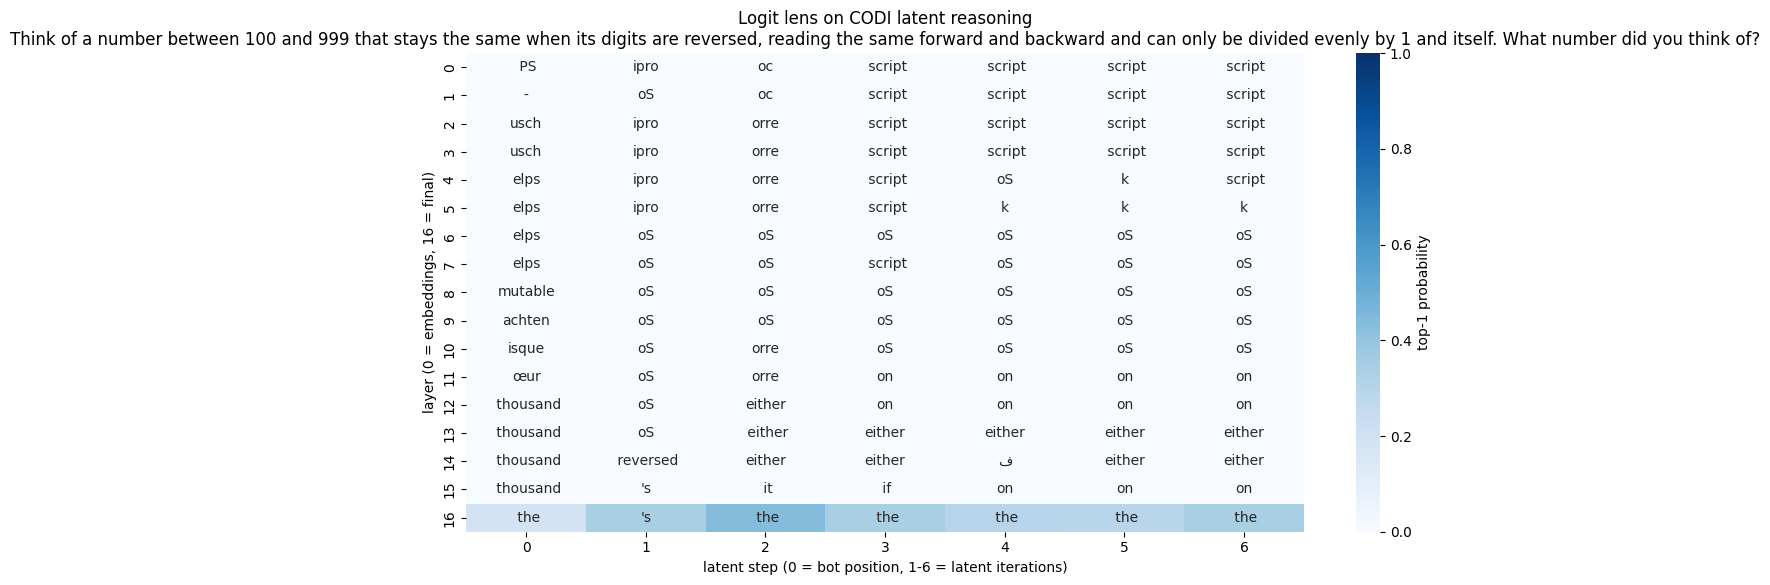

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

probs_grid = np.array(step_probs).T     # (num_layers+1, NUM_LATENT+1)
tokens_grid = np.array(step_tokens).T

fig, ax = plt.subplots(figsize=(1.6 * probs_grid.shape[1], 0.35 * probs_grid.shape[0]))
sns.heatmap(probs_grid, annot=tokens_grid, fmt="", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "top-1 probability"}, ax=ax)
ax.set_xlabel("latent step (0 = bot position, 1-6 = latent iterations)")
ax.set_ylabel("layer (0 = embeddings, 16 = final)")
ax.set_title(f"Logit lens on CODI latent reasoning\n{question}")
plt.tight_layout()
plt.show()

## Jacobian lens: a corrected readout of the latent vectors

Logit lens reads a hidden state by applying the model's own final norm +
`lm_head` directly, assuming layer *l*'s residual stream uses the same
"coordinate system" as the final layer. The [Jacobian lens](https://github.com/anthropics/jacobian-lens)
(companion code for *Verbalizable Representations Form a Global Workspace
in Language Models*, Anthropic 2026) corrects for this by first
transporting the vector through the actual averaged Jacobian `J_l =
E[∂h_final/∂h_l]`, fit on an ordinary text corpus, before decoding:
`lens_l(h) = unembed(J_l @ h)`.

`fit()`/`apply()` are text-prompt-only (`input_ids`), so — same limitation
as `transformer_utils.plot_logit_lens` earlier in this notebook — we fit
the lens on ordinary text, then apply `transport()` + `unembed()` by hand
inside our own CODI latent loop below.


In [ ]:
!git clone https://github.com/anthropics/jacobian-lens.git
%cd jacobian-lens
!pip install .
%cd ..


Cloning into 'jacobian-lens'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 70 (delta 10), reused 6 (delta 6), pack-reused 43 (from 1)
Receiving objects: 100% (70/70), 1.74 MiB | 29.17 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/jacobian-lens
Processing /content/jacobian-lens
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jlens: filename=jlens-0.1.0-py3-none-any.whl size=49953 sha256=105f41eb217a13486b04ec3f9554b73806bec43c7ddf5371f8e6440307dfbb29
  Stored in directory: /root/.cache/pip/wheels/9b/16/f6/ff5117e12d375117559a1ded186e4d458b172d145efd7f032b
Successfully built jlens
/content


In [ ]:
!pip install wandb

In [ ]:
import jlens
from jlens.examples import load_wikitext_prompts

wrapped_model = jlens.from_hf(model, tokenizer)   # auto-detects Llama's model.layers/norm/embed_tokens/lm_head

# A handful of layers spanning early/middle -- fit() shares backward passes
# across every source layer per prompt, so fitting 4 layers costs the same
# as fitting 1. Compare against layer 15 (== final, no transport needed)
# in the plot below.
SOURCE_LAYERS = [3, 5, 6, 8, 9, 11, 12, 14]

prompts = load_wikitext_prompts(n_prompts=500)   # README: quality saturates quickly; ~100 is usable


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

In [ ]:
import wandb, logging

wandb.login()  # prompts for your API key once, then caches it
wandb.init(
    project="jacobian-lens-codi-4",
    name="codi_llama1b_jlens_fit_4",
    config={"source_layers": SOURCE_LAYERS, "dim_batch": 8, "n_prompts": len(prompts)},
)

class WandbJlensHandler(logging.Handler):
    def emit(self, record):
        # Match only the per-prompt progress line -- fit() also logs a
        # startup summary, a resume notice, and a final "done" line, none
        # of which share this exact template.
        if record.levelno != logging.INFO or not isinstance(record.msg, str):
            return
        if not record.msg.startswith("  prompt "):
            return
        prompt_idx, total, seq_len, n_valid, elapsed, prompt_norm, mean_rel_change = record.args
        wandb.log({
            "seq_len": seq_len,
            "n_valid_positions": n_valid,
            "seconds_per_prompt": elapsed,
            "jacobian_norm": prompt_norm,
            "mean_rel_change": mean_rel_change,
        }, step=prompt_idx)

fitting_logger = logging.getLogger("jlens.fitting")   # matches `logger = logging.getLogger(__name__)` in fitting.py
fitting_logger.setLevel(logging.INFO)
fitting_logger.addHandler(WandbJlensHandler())

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akash-chand6891 (akash-chand6891-amazon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:

lens = jlens.fit(
    wrapped_model,
    prompts=prompts,
    source_layers=SOURCE_LAYERS,
    checkpoint_path=f"{JLENS_DIR}/codi_llama1b_jlens_ckpt_4.pt",   # resumable if interrupted
)
lens.save(f"{JLENS_DIR}/codi_llama1b_jlens_4.pt")
print(lens)


INFO:jlens.fitting:fit: n_layers=16 d_model=2048, fitting 8 source layers (target=L15) on 500 prompts
INFO:jlens.fitting:  resuming from checkpoint: 500/500 prompts processed
INFO:jlens.fitting:fit: done, 500 prompts


JacobianLens(d_model=2048, n_prompts=500, source_layers=[3..14] (8 layers))


In [ ]:
test_prompt = "Think of a number between 100 and 999 that stays the same when its digits are reversed, reading the same forward and backward and can only be divided evenly by 1 and itself. What number did you think of?"

lens_logits, model_logits, _ = lens.apply(wrapped_model, test_prompt, positions=[-1])

for layer in sorted(lens_logits):
    top5 = lens_logits[layer][0].topk(10).indices
    print(f"L{layer}:", [tokenizer.decode([t]) for t in top5])

print("model final:", [tokenizer.decode([t]) for t in model_logits[0].topk(10).indices])

L3: ['?', '<<', 'The', ' <<', '??', '<<(', '...', '..', '?!', '>>']
L5: ['?', '?\n\n', '<<', '?\n', '<<(', '!', '?!', 'The', '>>', '!?']
L6: [':', '<<(', '42', '106', '105', '66', '96', '92', '56', '&']
L8: ['<<', '<<(', 'The', 'Number', ' palindrome', '\\\\', 'Problem', '#', '##', 'π']
L9: ['The', '<<', '<<(', 'It', '##', 'This', 'When', ' The', 'From', '456']
L11: ['<<', '<<(', 'The', ' palindrome', 'Order', 'yll', '\\\\', 'eware', ' decryption', ' conson']
L12: ['<<', ' decryption', ' Encryption', '<<(', ' decrypt', ' palindrome', 'yll', '>>', ' digit', 'The']
L14: ['The', '<<', 'the', '<<(', ' The', ' the', 'THE', ' <<', ' THE', 'nThe']
model final: ['The', '<<', '<<(', '*', ' The', 'the', ' <<', '..', 'A', '+']


In [ ]:
# Re-run the same CODI latent loop as the cell above, decoding each source
# layer through the fitted J-lens instead of raw lm_head. The final layer
# (index 15) has no Jacobian to apply -- it's already in its own basis --
# so it's decoded the same way plain logit lens does.

def decode_layers_with_jlens(hidden_states_tuple):
    """hidden_states_tuple: outputs.hidden_states from one loop step.
    Returns (tokens, probs) lists ordered as SOURCE_LAYERS + ['final']."""
    tokens, probs = [], []

    for l in SOURCE_LAYERS:
        h = hidden_states_tuple[l + 1][:, -1, :]      # raw, pre-norm (hidden_states[0] = embeddings)
        transported = lens.transport(h, l)             # J_l @ h
        logits = wrapped_model.unembed(transported)     # final_norm + lm_head, handled for us
        p = F.softmax(logits, dim=-1)
        top_p, top_i = p.max(dim=-1)
        tokens.append(tokenizer.decode([top_i.item()]))
        probs.append(top_p.item())

    h_final = hidden_states_tuple[-1][:, -1, :]         # already normed -- do NOT call unembed() on this
    logits = model.lm_head(h_final)
    p = F.softmax(logits, dim=-1)
    top_p, top_i = p.max(dim=-1)
    tokens.append(tokenizer.decode([top_i.item()]))
    probs.append(top_p.item())

    return tokens, probs

jlens_step_tokens, jlens_step_probs = [], []

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                     use_cache=True, output_hidden_states=True)
    past_key_values = outputs.past_key_values
    steps_hidden = [outputs.hidden_states]
    tok, prob = decode_layers_with_jlens(outputs.hidden_states)
    jlens_step_tokens.append(tok); jlens_step_probs.append(prob)

    latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
    latent_embd = prj(latent_embd)

    for i in range(NUM_LATENT):
        outputs = model(inputs_embeds=latent_embd, use_cache=True,
                         output_hidden_states=True, past_key_values=past_key_values)
        past_key_values = outputs.past_key_values
        steps_hidden.append(outputs.hidden_states)
        tok, prob = decode_layers_with_jlens(outputs.hidden_states)
        jlens_step_tokens.append(tok); jlens_step_probs.append(prob)

        latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
        latent_embd = prj(latent_embd)


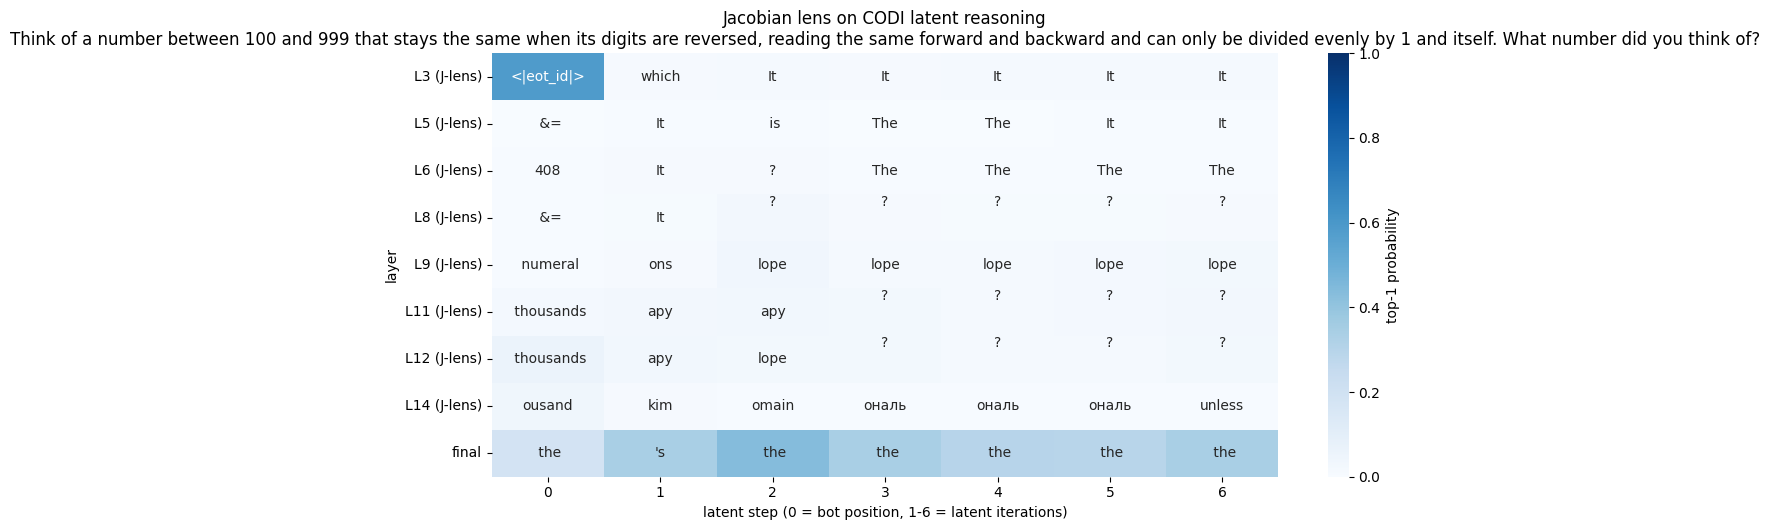

In [ ]:
probs_grid = np.array(jlens_step_probs).T      # (len(SOURCE_LAYERS)+1, NUM_LATENT+1)
tokens_grid = np.array(jlens_step_tokens).T
row_labels = [f"L{l} (J-lens)" for l in SOURCE_LAYERS] + ["final"]

fig, ax = plt.subplots(figsize=(1.6 * probs_grid.shape[1], 0.6 * probs_grid.shape[0]))
sns.heatmap(probs_grid, annot=tokens_grid, fmt="", cmap="Blues", vmin=0, vmax=1,
            yticklabels=row_labels, cbar_kws={"label": "top-1 probability"}, ax=ax)
ax.set_xlabel("latent step (0 = bot position, 1-6 = latent iterations)")
ax.set_ylabel("layer")
ax.set_title(f"Jacobian lens on CODI latent reasoning\n{question}")
plt.tight_layout()
plt.show()


In [ ]:
import re

def extract_number(token_str):
    m = re.search(r"-?\d+", token_str)
    return int(m.group()) if m else None


## J-space: sparse decomposition (for confirming Stage A candidates)

Top-1 J-lens decoding (Stage A below) is cheap but can be misleading on
its own -- a cell can show a strong top-1 hit rate while the vector is
still mostly noise (see the layer-6 result earlier in this project:
63.3% Stage A hit rate, yet 97.6% unexplained residual under sparse
decomposition, with an incoherent token list). Before recommending any
cell to the patching experiment, we confirm it here: does the
hypothesized concept survive as a genuinely sparse, low-residual,
dominant component -- not just the accidental top-1 pick?


In [ ]:
from jlens.vis import _meaningful_token_mask
from scipy.optimize import nnls

gain = model.model.norm.weight.detach()
W_U = model.lm_head.weight.detach()
word_mask = _meaningful_token_mask(tokenizer, W_U.shape[0], W_U.device)

_dictionary_cache = {}

def build_dictionary(layer):
    if layer not in _dictionary_cache:
        J_l = lens.jacobians[layer].to(W_U.device, W_U.dtype)
        atoms = (W_U[word_mask] * gain[None, :]) @ J_l
        atoms = atoms / atoms.norm(dim=1, keepdim=True).clamp_min(1e-8)
        token_ids = torch.nonzero(word_mask, as_tuple=True)[0]
        _dictionary_cache[layer] = (atoms, token_ids)
    return _dictionary_cache[layer]


def gradient_pursuit(x, atoms, token_ids, tokenizer, k=50, tol=1e-4):
    residual = x.clone().float()
    active = []
    coeffs = torch.zeros(0)
    for _ in range(k):
        scores = atoms @ residual
        scores[active] = float("-inf")
        best = torch.argmax(scores).item()
        active.append(best)

        A = atoms[active]
        coeffs_np, _ = nnls(A.T.cpu().numpy(), x.cpu().numpy())
        coeffs = torch.tensor(coeffs_np, dtype=x.dtype, device=x.device)

        recon = coeffs @ A
        residual = x - recon
        if residual.norm() < tol:
            break

    results = [(tokenizer.decode([token_ids[i].item()]), c.item())
               for i, c in zip(active, coeffs) if c.item() > 0]
    return sorted(results, key=lambda r: -r[1]), residual.norm().item() / x.norm().item()


def stage_c_confirm(h, layer, k=50, n_random_controls=7):
    """Run the real decomposition, plus N random-vector controls at the
    same scale, so a residual/coherence number can be judged against a
    noise floor rather than in isolation."""
    atoms, token_ids = build_dictionary(layer)
    concepts, residual_frac = gradient_pursuit(h, atoms, token_ids, tokenizer, k=k)

    control_residuals = []
    for _ in range(n_random_controls):
        random_h = torch.randn_like(h)
        random_h = random_h * (h.norm() / random_h.norm())
        _, r = gradient_pursuit(random_h, atoms, token_ids, tokenizer, k=k)
        control_residuals.append(r)

    return {
        "concepts": concepts,
        "residual_frac": residual_frac,
        "random_baseline_mean": sum(control_residuals) / len(control_residuals),
        "looks_real": residual_frac < (sum(control_residuals) / len(control_residuals)) - 0.05,
    }


In [ ]:
STEP = 4
LAYER = 12          # must be one of SOURCE_LAYERS
EXAMPLE_IDX = 0
STEPS_HIDDEN = steps_hidden   # or baseline_steps_hidden / reset_steps_hidden

h = STEPS_HIDDEN[STEP][LAYER + 1][:, -1, :].squeeze(0).float()
result = stage_c_confirm(h, LAYER)

print(f"residual: {result['residual_frac']:.1%}  (random baseline: {result['random_baseline_mean']:.1%})")
print(f"looks real (residual meaningfully below random baseline): {result['looks_real']}")
for token_str, coeff in result["concepts"][:52]:
    print(f"  {token_str!r:15s}  {coeff:.3f}")

residual: 97.6%  (random baseline: 98.6%)
looks real (residual meaningfully below random baseline): False
  ' tiles'         0.518
  'нг'             0.397
  ' верх'          0.384
  '押'              0.351
  ' prefix'        0.350
  'Numer'          0.338
  ' Cf'            0.302
  'onical'         0.299
  ' regs'          0.260
  ' negot'         0.255
  'esign'          0.244
  ' cheating'      0.239
  'گذ'             0.238
  ' corresponding'  0.230
  'тр'             0.225
  'еф'             0.223
  'зі'             0.223
  'омер'           0.209
  'azı'            0.203
  'чи'             0.201
  ' arbit'         0.198
  'orre'           0.196
  'ип'             0.183
  ' python'        0.177
  ' sle'           0.175
  ' tax'           0.172
  '녀'              0.165
  'Ђ'              0.163
  ' it'            0.154
  'ripple'         0.152
  ' wager'         0.148
  'agraph'         0.132
  '晓'              0.130
  'Except'         0.118
  ' Num'           0.114
  ' whether'      

/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 65414 (\N{HALFWIDTH KATAKANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 20329 (\N{CJK UNIFIED IDEOGRAPH-4F69}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 45367 (\N{HANGUL SYLLABLE NES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2054/3117903635.py:19: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans

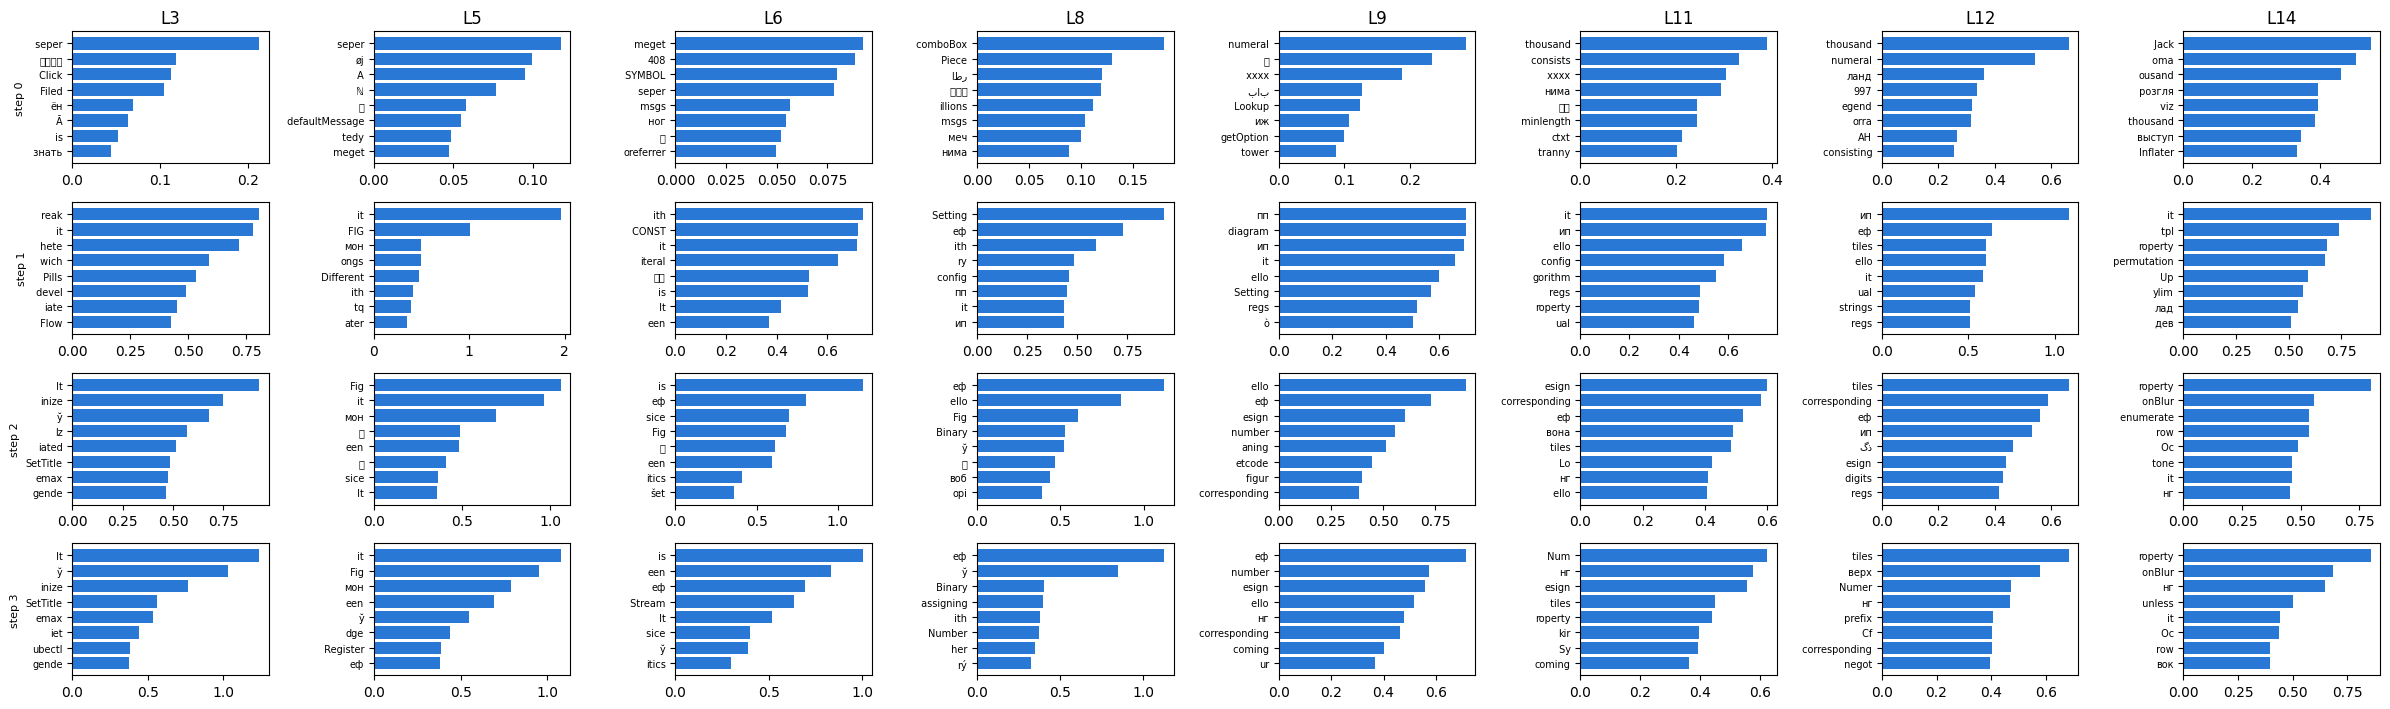

In [ ]:
def plot_jspace_grid(steps_hidden_list, steps, layers, k=25, k_display=8):
    fig, axes = plt.subplots(len(steps), len(layers), figsize=(3 * len(layers), 1.8 * len(steps)), squeeze=False)
    for i, step in enumerate(steps):
        for j, layer in enumerate(layers):
            ax = axes[i][j]
            h = steps_hidden_list[step][layer + 1][:, -1, :].squeeze(0).float()
            result = stage_c_confirm(h, layer, k=k)
            concepts = result["concepts"][:k_display]
            tokens, coeffs = zip(*concepts) if concepts else ([], [])

            ax.barh(range(len(tokens)), coeffs, color="#2a78d6")
            ax.set_yticks(range(len(tokens)))
            ax.set_yticklabels(tokens, fontsize=7)
            ax.invert_yaxis()
            if i == 0:
                ax.set_title(f"L{layer}")
            if j == 0:
                ax.set_ylabel(f"step {step}", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_jspace_grid(steps_hidden, steps=range(4), layers=SOURCE_LAYERS)

# Local Jacobian (VJP through the CODI loop) vs wikitext-fitted Jacobian lens
Cell 1 = config/helpers, cell 2 = text-fit side + differentiability check, cell 3 = sanity checks,
cell 4 = main experiment, cell 5 = analysis/plots.
Expects in scope: model, tokenizer, prj, lens, wrapped_model, NUM_LATENT, bot_id, eot_id.

In [ ]:
# Cell 1: config + helpers
import torch, numpy as np, pandas as pd
import torch.nn.functional as F

SRC_LAYERS = [3, 5, 6, 8, 9, 11, 12, 14]          # must match lens source_layers
N_PROMPTS = 50
SEED = 0
INCLUDE_ANSWER_TARGETS = False   # open choice: also add teacher-forced "eot + The answer is: N" positions as targets
TOKEN_STRS = [' 24', ' 48', ' 8', ' 12', ' 16', ' 3', ' 4', ' 5', ' 6', ' 9', ' 10', ' 18', ' 30', ' 36']
VARIANTS = ['feedback', 'nofeedback']

dev = next(model.parameters()).device
model.eval()
try:
    model.gradient_checkpointing_disable()
except Exception:
    pass
bb = model.model if hasattr(model.model, 'layers') else model.model.model   # handles a PEFT wrapper
embed = model.get_input_embeddings()
D = model.config.hidden_size
NS = 1 + NUM_LATENT                                # steps: 0 = bot position, 1..6 = latent calls
LI = {l: i for i, l in enumerate(SRC_LAYERS)}

def resolve_token(s):
    for cand in (s, s.strip()):
        ids = tokenizer.encode(cand, add_special_tokens=False)
        if len(ids) == 1:
            return ids[0], cand
    ids = tokenizer.encode(s, add_special_tokens=False)
    print(f'WARNING {s!r} is multi-token {ids}; using last piece')
    return ids[-1], s

tok_ids, tok_names = [], []
for s in TOKEN_STRS:
    i, used = resolve_token(s)
    if i not in tok_ids:
        tok_ids.append(i); tok_names.append(tokenizer.decode([i]))
K = len(tok_ids)
print('tokens:', list(zip(tok_names, tok_ids)))

g = bb.norm.weight.detach()
W = model.lm_head.weight.detach()[tok_ids]         # [K, D]
GW = (g[None, :] * W).float()                      # rows g ⊙ w_t

def make_prompt(X, Y, Z):
    # REPLACE with the exact template from your notebook if it differs
    q = (f"A team starts with {X} members. They recruit {Y} new members. "
         f"Then each current member recruits {Z} new members. How many members are there now?")
    return q, (X + Y) * (1 + Z)

def run_codi(question, answer, feedback, with_answer_targets=False):
    """CODI loop with the autograd graph alive. Returns block outputs per call and stacked target h_final."""
    cap = {l: [] for l in SRC_LAYERS}
    hf = []
    rec = {'on': True}
    def mk(l):
        def hook(mod, inp, out):
            cap[l].append(out[0] if isinstance(out, tuple) else out)
        return hook
    hooks = [bb.layers[l].register_forward_hook(mk(l)) for l in SRC_LAYERS]
    hooks.append(bb.norm.register_forward_pre_hook(lambda m, a: hf.append(a[0]) if rec['on'] else None))
    try:
        with torch.enable_grad():
            ids = tokenizer(question, return_tensors='pt').input_ids.to(dev)
            ids = torch.cat([ids, torch.tensor([[bot_id]], device=dev)], 1)
            emb = embed(ids).detach().requires_grad_(True)
            out = model(inputs_embeds=emb, use_cache=True)
            pkv = out.past_key_values
            for i in range(NUM_LATENT):
                rec['on'] = False
                lat = bb.norm(hf[-1][:, -1:, :])           # == hidden_states[-1] at last position
                rec['on'] = True
                x = prj(lat)
                if not feedback:
                    x = x.detach().requires_grad_(True)     # cut the prj feedback path
                out = model(inputs_embeds=x, past_key_values=pkv, use_cache=True)
                pkv = out.past_key_values
            tgt = [hf[0][0, -1]] + [hf[c][0, 0] for c in range(1, NS)]
            if with_answer_targets:
                seq = torch.tensor([[eot_id] + tokenizer.encode(f"The answer is: {answer}", add_special_tokens=False)],
                                   device=dev)
                e = embed(seq).detach().requires_grad_(True)
                model(inputs_embeds=e, past_key_values=pkv, use_cache=True)
                tgt += [hf[NS][0, p] for p in range(seq.shape[1])]
            tgt = torch.stack(tgt)                          # [n_targets, D]
    finally:
        for h in hooks:
            h.remove()
    return cap, hf, tgt

def source_vjps(cap, scal, retain=False):
    """scal: [K] scalars. Returns V [NS, len(SRC_LAYERS), K, D]: grad wrt block output at the latent-position of each call."""
    srcs = [cap[l][c] for l in SRC_LAYERS for c in range(NS)]
    V = torch.zeros(NS, len(SRC_LAYERS), K, D, device=dev)
    for k in range(K):
        grads = torch.autograd.grad(scal[k], srcs, retain_graph=(retain or k < K - 1), allow_unused=True)
        for li, l in enumerate(SRC_LAYERS):
            for c in range(NS):
                gr = grads[li * NS + c]
                if gr is not None:
                    V[c, li, k] = gr[0, -1] if c == 0 else gr[0, 0]
    return V


tokens: [('24', 1187), ('48', 2166), ('8', 23), ('12', 717), ('16', 845), ('3', 18), ('4', 19), ('5', 20), ('6', 21), ('9', 24), ('10', 605), ('18', 972), ('30', 966), ('36', 1927)]


In [ ]:
# Cell 2: text-fit side  J_l^T (g ⊙ w_t)  + differentiability check of lens.transport
def fit_autograd(l):
    h = torch.zeros(K, D, device=dev, requires_grad=True)
    with torch.enable_grad():
        y = lens.transport(h, l)
        assert y.shape[-1] == D, f'transport output {tuple(y.shape)} is not d_model-sized (unembed applied?)'
        y = y.reshape(K, D)
        (gr,) = torch.autograd.grad((y * GW).sum(), h)     # row k = J^T (g ⊙ w_k)
    return gr.detach()

def fit_matrix(l):
    with torch.no_grad():
        Y = lens.transport(torch.eye(D, device=dev), l).reshape(D, D)   # row i = J e_i  (affine offset removed below)
        Y0 = lens.transport(torch.zeros(1, D, device=dev), l).reshape(1, D)
        Jm = (Y - Y0).T                                                # [D_out, D_in]
        return GW @ Jm                                                 # rows = (J^T c_k)^T

FIT = torch.zeros(len(SRC_LAYERS), K, D, device=dev)
for l in SRC_LAYERS:
    try:
        a = fit_autograd(l)
        err = None
    except Exception as e:
        a, err = None, e
    m = fit_matrix(l) if (a is None or l == SRC_LAYERS[0]) else None
    if a is not None and m is not None:
        agree = F.cosine_similarity(a, m, dim=-1).mean().item()
        print(f'layer {l}: autograd vs explicit-matrix cosine = {agree:.6f}  (should be ~1)')
    if a is None:
        print(f'layer {l}: lens.transport not differentiable ({err!r}); using explicit matrix')
    FIT[LI[l]] = a if a is not None else m
print('fit norms per layer (mean over tokens):', FIT.norm(dim=-1).mean(-1).cpu().numpy().round(3))


layer 3: autograd vs explicit-matrix cosine = 1.000000  (should be ~1)
fit norms per layer (mean over tokens): [4.495 5.025 5.294 5.093 4.857 4.891 4.617 3.468]


In [ ]:
# Cell 3: sanity checks (hooks, causality, forward equivalence)
q, ans = make_prompt(3, 5, 2)
ids = tokenizer(q, return_tensors='pt').input_ids.to(dev)
ids = torch.cat([ids, torch.tensor([[bot_id]], device=dev)], 1)
with torch.no_grad():
    hs = model(input_ids=ids, output_hidden_states=True).hidden_states

capF, hfF, tgtF = run_codi(q, ans, feedback=True)
capN, hfN, tgtN = run_codi(q, ans, feedback=False)
print('n captures per layer:', {l: len(v) for l, v in capF.items()}, '| norm calls:', len(hfF))
for l in SRC_LAYERS:
    d = (capF[l][0].detach() - hs[l + 1]).abs().max().item()
    print(f'block {l} output vs hidden_states[{l+1}] max|diff| = {d:.2e}')
print('pre-norm h_final vs norm-hook: max|diff| to hidden_states[-1]:',
      (bb.norm(hfF[0].detach()) - hs[-1]).abs().max().item())
print('forward values identical across variants:', (tgtF - tgtN).abs().max().item())

# causality: a target at step 0 must not depend on a source at step 3
scal0 = (tgtF[0:1] @ GW.T).sum(0)                       # [K], step-0 target only
V0 = source_vjps(capF, scal0, retain=True)   # keep graph: capF is reused below
print('step-0 target -> grad at source step 3 (must be 0):', V0[3].abs().max().item(),
      '| at source step 0 (should be >0):', V0[0].abs().max().item())
# gradient at the last block should be shared by feedback / no feedback for the last step
for tag, cap_, tgt_ in (('feedback', capF, tgtF), ('nofeedback', capN, tgtN)):
    scal = (tgt_ @ GW.T).sum(0)
    V = source_vjps(cap_, scal)
    print(tag, 'VJP norms per step (layer 14, mean over tokens):', V[:, LI[14]].norm(dim=-1).mean(-1).cpu().numpy().round(3))


n captures per layer: {3: 7, 5: 7, 6: 7, 8: 7, 9: 7, 11: 7, 12: 7, 14: 7} | norm calls: 7
block 3 output vs hidden_states[4] max|diff| = 0.00e+00
block 5 output vs hidden_states[6] max|diff| = 0.00e+00
block 6 output vs hidden_states[7] max|diff| = 0.00e+00
block 8 output vs hidden_states[9] max|diff| = 0.00e+00
block 9 output vs hidden_states[10] max|diff| = 0.00e+00
block 11 output vs hidden_states[12] max|diff| = 0.00e+00
block 12 output vs hidden_states[13] max|diff| = 0.00e+00
block 14 output vs hidden_states[15] max|diff| = 0.00e+00
pre-norm h_final vs norm-hook: max|diff| to hidden_states[-1]: 0.0
forward values identical across variants: 0.0
step-0 target -> grad at source step 3 (must be 0): 0.0 | at source step 0 (should be >0): 1.1085705757141113
feedback VJP norms per step (layer 14, mean over tokens): [2.883 2.865 2.669 2.909 2.976 2.777 2.565]
nofeedback VJP norms per step (layer 14, mean over tokens): [2.689 2.528 2.438 2.967 2.951 2.782 2.565]


In [ ]:
# Cell 4: main experiment
def cos_mats(V, Fd):
    """V [NS,L,K,D], Fd [L,K,D] -> raw and token-mean-centred token x token cosines [NS,L,K,K]."""
    raw = torch.einsum('slad,lbd->slab', F.normalize(V, dim=-1), F.normalize(Fd, dim=-1))
    Vc = F.normalize(V - V.mean(2, keepdim=True), dim=-1)
    Fc = F.normalize(Fd - Fd.mean(1, keepdim=True), dim=-1)
    return raw, torch.einsum('slad,lbd->slab', Vc, Fc)

rng = np.random.RandomState(SEED)
prompts = [make_prompt(*rng.randint(1, 11, size=3)) for _ in range(N_PROMPTS)]
acc = {v: dict(raw=torch.zeros(NS, len(SRC_LAYERS), K, K, device=dev),
               cen=torch.zeros(NS, len(SRC_LAYERS), K, K, device=dev),
               Vsum=torch.zeros(NS, len(SRC_LAYERS), K, D, device=dev),
               diag_raw=[], diag_cen=[]) for v in VARIANTS}
for n, (q, ans) in enumerate(prompts):
    for v in VARIANTS:
        cap, hf, tgt = run_codi(q, ans, feedback=(v == 'feedback'), with_answer_targets=INCLUDE_ANSWER_TARGETS)
        V = source_vjps(cap, (tgt @ GW.T).sum(0))
        raw, cen = cos_mats(V, FIT)
        a = acc[v]
        a['raw'] += raw; a['cen'] += cen; a['Vsum'] += V
        a['diag_raw'].append(torch.diagonal(raw, dim1=-2, dim2=-1).cpu())
        a['diag_cen'].append(torch.diagonal(cen, dim1=-2, dim2=-1).cpu())
        del cap, hf, tgt, V
    if (n + 1) % 10 == 0:
        print(f'{n+1}/{N_PROMPTS} prompts')


In [ ]:
# Cell 5: analysis
def summarize(M):
    """M [NS,L,K,K] -> dict of [NS,L] arrays: diag mean, off-diag mean, top-1 row accuracy."""
    diag = torch.diagonal(M, dim1=-2, dim2=-1)
    off = (M.sum((-1, -2)) - diag.sum(-1)) / (K * K - K)
    top1 = (M.argmax(-1) == torch.arange(K, device=M.device)).float().mean(-1)
    return dict(diag=diag.mean(-1).cpu().numpy(), off=off.cpu().numpy(), top1=top1.cpu().numpy())

def table(x, title):
    df = pd.DataFrame(x.T, index=[f'L{l}' for l in SRC_LAYERS], columns=[f'step{s}' for s in range(NS)])
    print(f'\n{title}'); print(df.round(3).to_string())

res = {}
for v in VARIANTS:
    a = acc[v]
    Mraw, Mcen = a['raw'] / N_PROMPTS, a['cen'] / N_PROMPTS
    praw, pcen = cos_mats(a['Vsum'] / N_PROMPTS, FIT)                 # cosine of prompt-averaged VJP
    res[v] = dict(raw=summarize(Mraw), cen=summarize(Mcen), pooled_cen=summarize(pcen), Mraw=Mraw, Mcen=Mcen, pcen=pcen)
    print(f'\n================ {v} ================')
    table(res[v]['raw']['diag'], 'raw matched-token cosine (mean over prompts)')
    table(res[v]['raw']['off'],  'raw mismatched-token cosine (baseline: shared g⊙w component)')
    table(res[v]['cen']['diag'] - res[v]['cen']['off'], 'centred: diag - offdiag cosine')
    table(res[v]['cen']['top1'], 'centred: top-1 row accuracy (chance = %.3f)' % (1 / K))
    table(res[v]['pooled_cen']['top1'], 'centred, prompt-averaged VJP: top-1 row accuracy')

import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, len(VARIANTS), figsize=(6 * len(VARIANTS), 8), squeeze=False)
for j, v in enumerate(VARIANTS):
    for i, (key, ttl) in enumerate((('cen', 'centred diag-offdiag'), ('raw', 'raw diag-offdiag'))):
        z = (res[v][key]['diag'] - res[v][key]['off']).T
        im = axs[i, j].imshow(z, aspect='auto', cmap='viridis')
        axs[i, j].set_xticks(range(NS)); axs[i, j].set_yticks(range(len(SRC_LAYERS)))
        axs[i, j].set_yticklabels([f'L{l}' for l in SRC_LAYERS]); axs[i, j].set_xlabel('step (0 = bot)')
        axs[i, j].set_title(f'{v}: {ttl}'); plt.colorbar(im, ax=axs[i, j])
plt.tight_layout(); plt.show()

LAYER_VIEW, STEP_VIEW = 8, 3
fig, axs = plt.subplots(1, 2 * len(VARIANTS), figsize=(6 * 2 * len(VARIANTS), 5))
k = 0
for v in VARIANTS:
    for key in ('Mraw', 'Mcen'):
        im = axs[k].imshow(res[v][key][STEP_VIEW, LI[LAYER_VIEW]].cpu().numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
        axs[k].set_xticks(range(K)); axs[k].set_yticks(range(K))
        axs[k].set_xticklabels(tok_names, rotation=90); axs[k].set_yticklabels(tok_names)
        axs[k].set_xlabel('text-fit token'); axs[k].set_ylabel('local-VJP token')
        axs[k].set_title(f'{v} {key[1:]} | L{LAYER_VIEW} step {STEP_VIEW}'); plt.colorbar(im, ax=axs[k]); k += 1
plt.tight_layout(); plt.show()


## Activation patching: causal necessity of the latent vectors

Four scenarios, each substituting a different replacement vector at latent
step i before letting steps i+1..NUM_LATENT and the final answer regenerate:
random noise (matched to the real per-step mean/std), a within-example
cumulative mean, a population mean ablation, and a resample from a
different example. See the `activation-patching-experiment` project doc
for the full design rationale.


In [ ]:
# --- question generator (matches the AlignmentForum paper's own template) ---
import random

def make_question(X, Y, Z):
    q = (f"A team starts with {X} members. They recruit {Y} new members. "
         f"Then each current member recruits {Z} additional people. "
         f"How many people are there now on the team? "
         f"Give the answer only and nothing else.")
    answer = (X + Y) * (1 + Z)
    return q, answer

def make_batch(n, seed=0, lo=1, hi=10):
    rng = random.Random(seed)
    batch = []
    for _ in range(n):
        X, Y, Z = rng.randint(lo, hi), rng.randint(lo, hi), rng.randint(lo, hi)
        q, ans = make_question(X, Y, Z)
        batch.append({"X": X, "Y": Y, "Z": Z, "question": q, "answer": ans})
    return batch


In [ ]:
# --- clean rollout: snapshot the KV cache + fed latent vector at each step ---
import copy

def encode_prompt(question):
    enc = tokenizer(question, return_tensors="pt").to(model.device)
    bot_tensor = torch.tensor([[bot_id]], device=model.device)
    input_ids = torch.cat([enc["input_ids"], bot_tensor], dim=1)
    attention_mask = torch.cat([enc["attention_mask"], torch.ones_like(bot_tensor)], dim=1)
    return input_ids, attention_mask

def run_clean_rollout(question):
    """Run prompt -> NUM_LATENT latent steps. Snapshots the KV cache right
    BEFORE each latent forward call and the exact (post-prj) vector fed in
    at that step, so any step can later be replayed with a substituted
    vector without recomputing the prefix from scratch."""
    input_ids, attention_mask = encode_prompt(question)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                         use_cache=True, output_hidden_states=True)
        past_key_values = outputs.past_key_values
        latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        pre_step_cache, fed_vectors = [], []

        for i in range(NUM_LATENT):
            pre_step_cache.append(copy.deepcopy(past_key_values))
            fed_vectors.append(latent_embd.clone())

            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        final_cache = copy.deepcopy(past_key_values)

    return {"pre_step_cache": pre_step_cache, "fed_vectors": fed_vectors, "final_cache": final_cache}


In [ ]:
# --- continue from a (possibly patched) step through to a decoded answer ---
def generate_answer(past_key_values, next_embd, max_new_tokens=200):
    generated_ids = []
    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            logits = outputs.logits[:, -1, :ori_vocab_size + 2]
            next_id = torch.argmax(logits, dim=-1)
            if next_id.item() == tokenizer.eos_token_id:
                break
            generated_ids.append(next_id.item())
            next_embd = model.model.embed_tokens(next_id.unsqueeze(0))
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

def clean_answer(rollout):
    eot_embd = model.model.embed_tokens(torch.tensor([[ori_vocab_size + 2]], device=model.device))
    return generate_answer(copy.deepcopy(rollout["final_cache"]), eot_embd)

# def continue_from_step(rollout, patch_step, patched_vector):
#     """Substitute `patched_vector` as the input to latent step `patch_step`
#     (1-indexed, 1..NUM_LATENT), replay the remaining latent steps normally,
#     then generate the final answer."""
#     past_key_values = copy.deepcopy(rollout["pre_step_cache"][patch_step - 1])
#     latent_embd = patched_vector

#     with torch.no_grad():
#         for i in range(patch_step - 1, NUM_LATENT):
#             outputs = model(inputs_embeds=latent_embd, use_cache=True,
#                              output_hidden_states=True, past_key_values=past_key_values)
#             past_key_values = outputs.past_key_values
#             latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

#     eot_embd = model.model.embed_tokens(torch.tensor([[ori_vocab_size + 2]], device=model.device))
#     return generate_answer(past_key_values, eot_embd)
def continue_from_step(rollout, patch_step, patched_vector):
    """Substitute `patched_vector` as the input to latent step `patch_step`
    (1-indexed), replay the REST of THIS ROLLOUT'S OWN latent steps, then
    generate. Uses len(rollout["pre_step_cache"]) rather than the global
    NUM_LATENT, so a stale rollout built under a different NUM_LATENT can
    never silently desync from this call again."""
    n_steps = len(rollout["pre_step_cache"])
    past_key_values = copy.deepcopy(rollout["pre_step_cache"][patch_step - 1])
    latent_embd = patched_vector

    with torch.no_grad():
        for i in range(patch_step - 1, n_steps):
            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

    eot_embd = model.model.embed_tokens(torch.tensor([[ori_vocab_size + 2]], device=model.device))
    return generate_answer(past_key_values, eot_embd)

In [ ]:
# --- the four patch-vector constructors ---
# def compute_population_stats(rollouts):
#     step_means, step_stds = [], []
#     for i in range(NUM_LATENT):
#         stacked = torch.cat([r["fed_vectors"][i] for r in rollouts], dim=0)
#         step_means.append(stacked.mean(dim=0, keepdim=True))
#         step_stds.append(stacked.std(dim=0, keepdim=True))
#     return step_means, step_stds

def compute_population_stats(rollouts):
    n_steps = len(rollouts[0]["fed_vectors"])   # derive from the data, not the global
    step_means, step_stds = [], []
    for i in range(n_steps):
        stacked = torch.cat([r["fed_vectors"][i] for r in rollouts], dim=0)
        step_means.append(stacked.mean(dim=0, keepdim=True))
        step_stds.append(stacked.std(dim=0, keepdim=True))
    return step_means, step_stds

def random_patch(step_means, step_stds, step_idx):
    """Gaussian noise centered on / scaled to the real per-step mean & std
    -- keeps the vector in the same region of space as genuine latent
    vectors, rather than an arbitrary out-of-scale vector."""
    mu, sigma = step_means[step_idx - 1], step_stds[step_idx - 1]
    return mu + sigma * torch.randn_like(mu)

def cumulative_patch(rollout, step_idx):
    """Running mean of THIS example's own latent vectors, steps 1..step_idx."""
    vecs = rollout["fed_vectors"][:step_idx]
    return torch.stack(vecs, dim=0).mean(dim=0)

def mean_ablation_patch(step_means, step_idx):
    """Population mean of the step-idx vector across the whole batch."""
    return step_means[step_idx - 1]

def resample_patch(rollouts, step_idx, exclude_idx):
    """A real latent vector from a DIFFERENT example, same step index."""
    other = random.choice([j for j in range(len(rollouts)) if j != exclude_idx])
    return rollouts[other]["fed_vectors"][step_idx - 1]


In [ ]:
# --- batched scenario patching: run all 4 scenarios in ONE forward pass per
#     step, instead of 4 sequential ones. Safe to batch with zero padding
#     since all 4 scenarios share the exact same prefix/cache for a given
#     (example, step) -- only the fed-in vector differs. ---

def replicate_cache(cache, B):
    """Expand a batch-1 KV cache to batch-B so B independent continuations
    can share the same prefix computation in one batched forward pass."""
    new_cache = copy.deepcopy(cache)
    for layer in new_cache.layers:
        layer.keys = layer.keys.expand(B, -1, -1, -1).clone()
        layer.values = layer.values.expand(B, -1, -1, -1).clone()
    return new_cache


def generate_answer_batched(past_key_values, next_embd, max_new_tokens=200):
    """Same as generate_answer, but B sequences at once. Tracks per-example
    early stopping with a `finished` mask -- no padding needed since every
    row started this call at the exact same real sequence length."""
    B = next_embd.shape[0]
    generated_ids = [[] for _ in range(B)]
    finished = [False] * B

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            logits = outputs.logits[:, -1, :ori_vocab_size + 2]
            next_ids = torch.argmax(logits, dim=-1)  # [B]

            for b in range(B):
                if finished[b]:
                    continue
                if next_ids[b].item() == tokenizer.eos_token_id:
                    finished[b] = True
                else:
                    generated_ids[b].append(next_ids[b].item())

            if all(finished):
                break
            next_embd = model.model.embed_tokens(next_ids).unsqueeze(1)

    return [tokenizer.decode(ids, skip_special_tokens=True) for ids in generated_ids]


def continue_from_step_batched(rollout, patch_step, patched_vectors):
    """patched_vectors: [B, 1, hidden] -- one row per scenario, all
    continuing from the SAME (example, step) cache."""
    B = patched_vectors.shape[0]
    n_steps = len(rollout["pre_step_cache"])
    past_key_values = replicate_cache(rollout["pre_step_cache"][patch_step - 1], B)
    latent_embd = patched_vectors

    with torch.no_grad():
        for i in range(patch_step - 1, n_steps):
            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

    eot_embd = model.model.embed_tokens(
        torch.tensor([[ori_vocab_size + 2]], device=model.device)
    ).expand(B, -1, -1)
    pre_eot_cache = copy.deepcopy(past_key_values)
    patched_texts = generate_answer_batched(past_key_values, eot_embd)
    return patched_texts, pre_eot_cache


In [ ]:
def batched_answer_logprob(past_key_values, answer_text, B):
    """Teacher-forced total log-prob of `answer_text`, computed for all B
    scenario rows at once -- they share the same ground truth (patching
    changes the prediction, not the correct answer). past_key_values must
    be continue_from_step_batched's second return value."""
    ids = tokenizer(f" {answer_text}", add_special_tokens=False, return_tensors="pt").input_ids.to(model.device)
    ids = ids.expand(B, -1)

    embed_tokens = model.model.embed_tokens
    eot_id = ori_vocab_size + 2
    next_embd = embed_tokens(torch.tensor([[eot_id]] * B, device=model.device))

    total_logprob = torch.zeros(B, device=model.device)
    with torch.no_grad():
        for i in range(ids.shape[1]):
            outputs = model(inputs_embeds=next_embd, use_cache=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            logp = F.log_softmax(outputs.logits[:, -1, :ori_vocab_size + 2], dim=-1)
            total_logprob += logp[torch.arange(B, device=model.device), ids[:, i]]
            next_embd = embed_tokens(ids[:, i:i+1])

    return total_logprob.tolist()

In [ ]:

def is_correct(decoded_text, answer):
    nums = re.findall(r"-?\d+", decoded_text)
    return bool(nums) and int(nums[0]) == answer

In [ ]:
import copy
import pandas as pd

# --- 1. run a "full" rollout that also keeps every layer's hidden state
#     per step (needed as the donor source for layer-level patches) ---
def run_clean_rollout_full(question, num_latent=NUM_LATENT):
    input_ids, attention_mask = encode_prompt(question)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                         use_cache=True, output_hidden_states=True)
        past_key_values = outputs.past_key_values
        latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        pre_step_cache, fed_vectors, steps_hidden = [], [], []
        for i in range(num_latent):
            pre_step_cache.append(copy.deepcopy(past_key_values))
            fed_vectors.append(latent_embd.clone())

            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            steps_hidden.append(outputs.hidden_states)   # all 17 layers, THIS step
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        final_cache = copy.deepcopy(past_key_values)

    return {"pre_step_cache": pre_step_cache, "fed_vectors": fed_vectors,
            "steps_hidden": steps_hidden, "final_cache": final_cache}


# --- 2. a forward hook that overwrites ONE layer's output for ONE call ---
def make_patch_hook(replacement):
    def hook(module, inputs, output):
        if isinstance(output, tuple):
            return (replacement,) + output[1:]
        return replacement
    return hook


# --- 3. patch rollout_a at (patch_step, patch_layer) with `replacement`,
#     then replay the REMAINING latent steps normally, then generate ---
def continue_from_layer_patch(rollout_a, patch_step, patch_layer, replacement):
    n_steps = len(rollout_a["pre_step_cache"])
    past_key_values = copy.deepcopy(rollout_a["pre_step_cache"][patch_step - 1])
    latent_embd = rollout_a["fed_vectors"][patch_step - 1]

    handle = model.model.layers[patch_layer].register_forward_hook(make_patch_hook(replacement))
    try:
        outputs = model(inputs_embeds=latent_embd, use_cache=True,
                         output_hidden_states=True, past_key_values=past_key_values)
    finally:
        handle.remove()   # patch applies to exactly this one call
    past_key_values = outputs.past_key_values
    latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

    with torch.no_grad():
        for i in range(patch_step, n_steps):
            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

    eot_embd = model.model.embed_tokens(torch.tensor([[ori_vocab_size + 2]], device=model.device))
    return generate_answer(past_key_values, eot_embd)


# --- 4. run it: A's every (step, layer) patched with B's activation ---
question_a, answer_a = "3 members each hire 5 people. How many members are there in total?", 18
question_b, answer_b = "3 managers each hire 7 people. How many members are there in total?", 24

rollout_a = run_clean_rollout_full(question_a)
rollout_b = run_clean_rollout_full(question_b)
print("A clean:", clean_answer(rollout_a))   # sanity check -- should say 18
print("B clean:", clean_answer(rollout_b))   # sanity check -- should say 24

LAYERS_TO_TEST = list(range(model.config.num_hidden_layers))  # all 16; narrow to SOURCE_LAYERS for speed

records = []
for step in range(1, NUM_LATENT + 1):
    for layer in LAYERS_TO_TEST:
        replacement = rollout_b["steps_hidden"][step - 1][layer + 1][:, -1:, :].clone()

        n_steps = len(rollout_a["pre_step_cache"])
        past_key_values = copy.deepcopy(rollout_a["pre_step_cache"][step - 1])
        latent_embd = rollout_a["fed_vectors"][step - 1]

        handle = model.model.layers[layer].register_forward_hook(make_patch_hook(replacement))
        try:
            with torch.no_grad():
                outputs = model(inputs_embeds=latent_embd, use_cache=True,
                                 output_hidden_states=True, past_key_values=past_key_values)
        finally:
            handle.remove()
        past_key_values = outputs.past_key_values
        latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        with torch.no_grad():
            for i in range(step, n_steps):
                outputs = model(inputs_embeds=latent_embd, use_cache=True,
                                 output_hidden_states=True, past_key_values=past_key_values)
                past_key_values = outputs.past_key_values
                latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        eot_embd = model.model.embed_tokens(torch.tensor([[ori_vocab_size + 2]], device=model.device))
        lp_18 = answer_logprob_number_only(copy.deepcopy(past_key_values), "18")
        lp_24 = answer_logprob_number_only(copy.deepcopy(past_key_values), "24")

        print(f"step={step:2d} layer={layer:2d}  logprob(18)={lp_18:7.3f}  logprob(24)={lp_24:7.3f}")
        records.append({"step": step, "layer": layer, "logprob_18": lp_18, "logprob_24": lp_24,
                         "shift": lp_24 - lp_18})

results_df = pd.DataFrame(records)

In [ ]:
grid = results_df.pivot(index="step", columns="layer", values="shift")
fig, ax = plt.subplots(figsize=(1.1 * len(LAYERS_TO_TEST), 0.5 * NUM_LATENT + 1))
sns.heatmap(grid, cmap="RdBu_r", center=0, cbar_kws={"label": "logprob(24) - logprob(18)"}, ax=ax)
ax.set_xlabel("layer"); ax.set_ylabel("latent step")
plt.tight_layout(); plt.show()

In [ ]:
# --- run across a batch and summarize (scenario-batched: 1 forward pass
#     per (example, step) instead of 4) ---
import re


N_QUESTIONS = 300   # smoke test; scale up once this runs cleanly
batch = make_batch(N_QUESTIONS, seed=0)
rollouts = [run_clean_rollout(ex["question"]) for ex in batch]
step_means, step_stds = compute_population_stats(rollouts)


# SCENARIO_NAMES = ["random_noise", "cumulative_mean", "population_mean", "resample"]

# records = []
# for idx, (ex, rollout) in enumerate(zip(batch, rollouts)):
#     clean_text = clean_answer(rollout)
#     clean_ok = is_correct(clean_text, ex["answer"])

#     for step in range(1, NUM_LATENT + 1):
#         vecs = torch.cat([
#             random_patch(step_means, step_stds, step),
#             cumulative_patch(rollout, step),
#             mean_ablation_patch(step_means, step),
#             resample_patch(rollouts, step, idx),
#         ], dim=0)  # [4, 1, hidden] -- one row per scenario

#         patched_texts = continue_from_step_batched(rollout, step, vecs)

#         for name, patched_text in zip(SCENARIO_NAMES, patched_texts):
#             records.append({
#                 "example": idx, "step": step, "scenario": name,
#                 "ground_truth": ex["answer"], "clean_answer": clean_text, "clean_correct": clean_ok,
#                 "patched_answer": patched_text, "patched_correct": is_correct(patched_text, ex["answer"]),
#             })

SCENARIO_NAMES = ["random_noise", "cumulative_mean", "population_mean", "resample", "no_patch"]

records = []
for idx, (ex, rollout) in enumerate(zip(batch, rollouts)):
    clean_text = clean_answer(rollout)
    clean_ok = is_correct(clean_text, ex["answer"])

    for step in range(1, NUM_LATENT + 1):
        vecs = torch.cat([
            random_patch(step_means, step_stds, step),
            cumulative_patch(rollout, step),
            mean_ablation_patch(step_means, step),
            resample_patch(rollouts, step, idx),
            rollout["fed_vectors"][step - 1],   # no_patch: this example's own real vector
        ], dim=0)

        patched_texts, pre_eot_cache = continue_from_step_batched(rollout, step, vecs)
        patched_logprobs = batched_answer_logprob(pre_eot_cache, str(ex["answer"]), vecs.shape[0])

        for name, patched_text, logprob in zip(SCENARIO_NAMES, patched_texts, patched_logprobs):
            records.append({
                "example": idx, "step": step, "scenario": name,
                "ground_truth": ex["answer"], "clean_answer": clean_text, "clean_correct": clean_ok,
                "patched_answer": patched_text, "patched_correct": is_correct(patched_text, ex["answer"]),
                "patched_logprob": logprob,
            })
results = pd.DataFrame(records)

# accuracy retained after patching, per (scenario, step) -- only among examples
# CODI already got right unpatched
summary = (results[results.clean_correct]
           .groupby(["scenario", "step"])["patched_correct"].mean().unstack("scenario"))
summary


In [ ]:
import matplotlib.pyplot as plt

# fixed color + marker per scenario -- assigned explicitly, never auto-cycled,
# so identity stays consistent across reruns/plots
scenario_style = {
    "random_noise":    {"color": "#2a78d6", "marker": "o"},
    "cumulative_mean": {"color": "#eb6834", "marker": "s"},
    "population_mean": {"color": "#1baf7a", "marker": "^"},
    "resample":        {"color": "#eda100", "marker": "D"},
}

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.axhline(1.0, color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
ax.text(summary.index.max(), 1.01, "baseline (100% correct pre-patch)",
        ha="right", va="bottom", fontsize=8, color="#898781")

for scenario in summary.columns:
    style = scenario_style.get(scenario, {})
    ax.plot(summary.index, summary[scenario], label=scenario,
            linewidth=2, markersize=7, **style)

ax.set_xlabel("latent step patched")
ax.set_ylabel("accuracy after patching")
ax.set_title("Accuracy retained after patching each latent step, by scenario")
ax.set_ylim(0, 1.08)
ax.set_xticks(summary.index)
ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(1.0, 0.0))

plt.tight_layout()
plt.show()

In [ ]:
n_correct = sum(is_correct(clean_answer(r), ex["answer"]) for ex, r in zip(batch, rollouts))
print(f"{n_correct}/{len(batch)}")

In [ ]:
r = rollouts[0]
for i, c in enumerate(r["pre_step_cache"]):
    print("step", i, "cached length:", c.layers[0].keys.shape[-2])
print("final cache length:", r["final_cache"].layers[0].keys.shape[-2])

In [ ]:
rollout = rollouts[0]
print("clean:", repr(clean_answer(rollout)))
for step in [1,5, 6]:
    v = random_patch(step_means, step_stds, step)
    print(f"step {step} random-patched:", repr(continue_from_step(rollout, step, v)))

In [ ]:
rollout = rollouts[0]
ex = batch[0]
n_steps = len(rollout["pre_step_cache"])
print("ground truth:", ex["answer"], "| question:", ex["question"])
print("clean:", repr(clean_answer(rollout)))
for step in [1, max(1, n_steps // 2), n_steps]:
    v = random_patch(step_means, step_stds, step)
    print(f"step {step} random-patched:", repr(continue_from_step(rollout, step, v)))

## Counterfactual-op activation patching

Staged plan (each stage is its own cell, run in order):

1. **`none` + `irrelevant`** -- baseline control. Confirms that inserting
   *any* extra clause, regardless of content, doesn't by itself disrupt
   the X+Y representation -- needed before trusting stage 2's results.
2. **`none` + `subtract` + `dissolve`** -- same-shape arithmetic variant,
   plus a structural discontinuity (answer forced to 0).
3. **`reset_to_earlier`** -- standalone, not blended into the stage 2
   population stats (a genuinely different question: does the *final
   answer* get routed to an *earlier* intermediate, X+Y itself, rather
   than the running total). Sharpest single test of "value gets routed
   to output."
4. `preempt` (order-sensitivity) and `threshold` (conditional branching)
   are deliberately **not** included here -- each is its own mini-study
   with a different population-stats population, left as a follow-up
   once 1-3 are validated.

Each stage runs Stage A (cheap, broad J-lens scan) first, then Stage C
(J-space sparse decomposition + random-vector control) on whichever
cell Stage A flags, to confirm the signal is real before recommending
it to Stage B (patching, reusing the machinery from the section above).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_stage_a(table, ops, steps=None, layers=None, title=""):
    """table: the pivot table from run_stage_a (index=[step, layer], columns=op)."""
    steps = steps if steps is not None else sorted(table.index.get_level_values("step").unique())
    layers = layers if layers is not None else [f"L{l}" for l in SOURCE_LAYERS] + ["final"]

    fig, axes = plt.subplots(1, len(ops), figsize=(4 * len(ops), 0.5 * len(steps) + 1.5), sharey=True)
    if len(ops) == 1:
        axes = [axes]

    for ax, op in zip(axes, ops):
        grid = table[op].unstack("layer").reindex(index=steps, columns=layers)
        sns.heatmap(grid, vmin=0, vmax=1, cmap="Blues", annot=True, fmt=".2f",
                    cbar=(ax is axes[-1]), ax=ax)
        ax.set_title(op)
        ax.set_xlabel("layer")
    axes[0].set_ylabel("latent step")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
import random

BASE_TEMPLATE = (
    "A team starts with {X} members. They recruit {Y} new members. "
    "Then each current member recruits {Z} additional people."
)
COUNTERFACTUAL_CLAUSES = {
    "none":     "",
    "subtract": " Then {K} members leave.",
    "dissolve": " Then the team is dissolved.",
}
QUESTION_SUFFIX = " How many people are there now on the team? Give the answer only and nothing else."

# --- Stage 0: none vs irrelevant baseline (establishes whether ANY extra
#     clause disrupts X+Y, independent of arithmetic relevance) ---

IRRELEVANT_CLAUSES = [
    " The team wears blue jerseys.",
    " The manager schedules a meeting for next week.",
    " It starts raining during practice.",
]

def make_question_baseline(X, Y, Z, op, rng):
    base_total = (X + Y) * (1 + Z)
    clause = "" if op == "none" else rng.choice(IRRELEVANT_CLAUSES)
    q = BASE_TEMPLATE.format(X=X, Y=Y, Z=Z) + clause + QUESTION_SUFFIX
    return q, base_total

def make_batch_baseline(n, seed=0, lo=1, hi=10, op_weights={"none": 0.5, "irrelevant": 0.5}):
    rng = random.Random(seed)
    ops = list(op_weights.keys())
    weights = list(op_weights.values())
    batch = []
    for _ in range(n):
        X, Y, Z = rng.randint(lo, hi), rng.randint(lo, hi), rng.randint(lo, hi)
        op = rng.choices(ops, weights=weights, k=1)[0]
        q, ans = make_question_baseline(X, Y, Z, op, rng)
        batch.append({"X": X, "Y": Y, "Z": Z, "op": op, "question": q, "answer": ans})
    return batch


def candidate_matches_baseline(tok_str, ex):
    n = extract_number(tok_str)
    if n == ex["X"] + ex["Y"]:
        return "X+Y"
    if n == ex["answer"]:
        return "final"
    return None


def run_stage_a(batch_examples, candidate_fn, op_names):
    """Shared Stage A scan: returns a hit-rate DataFrame and the raw
    steps_hidden per example (reused by Stage C to pull the actual vector
    at whichever cell looks strongest)."""
    layer_labels = [f"L{l}" for l in SOURCE_LAYERS] + ["final"]
    hits = {s: {ll: {op: 0 for op in op_names} for ll in layer_labels} for s in range(NUM_LATENT + 1)}
    counts = {op: 0 for op in op_names}
    all_steps_hidden = []

    for ex in batch_examples:
        counts[ex["op"]] += 1
        input_ids, attention_mask = encode_prompt(ex["question"])

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                             use_cache=True, output_hidden_states=True)
            past_key_values = outputs.past_key_values
            steps_hidden = [outputs.hidden_states]
            latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))
            for i in range(NUM_LATENT):
                outputs = model(inputs_embeds=latent_embd, use_cache=True,
                                 output_hidden_states=True, past_key_values=past_key_values)
                past_key_values = outputs.past_key_values
                steps_hidden.append(outputs.hidden_states)
                latent_embd = prj(outputs.hidden_states[-1][:, -1, :].unsqueeze(1))

        all_steps_hidden.append(steps_hidden)
        for step, hs in enumerate(steps_hidden):
            toks, _ = decode_layers_with_jlens(hs)
            for layer_label, tok in zip(layer_labels, toks):
                match = candidate_fn(tok, ex)
                if match:
                    hits[step][layer_label][ex["op"]] += 1

    rows = []
    for step, per_layer in hits.items():
        for layer_label, per_op in per_layer.items():
            for op, count in per_op.items():
                rows.append({"step": step, "layer": layer_label, "op": op,
                             "hit_rate": count / max(1, counts[op])})
    df = pd.DataFrame(rows)
    return df.pivot_table(index=["step", "layer"], columns="op", values="hit_rate"), all_steps_hidden


N_BASELINE = 300
baseline_batch = make_batch_baseline(N_BASELINE, seed=0)
baseline_table, baseline_steps_hidden = run_stage_a(baseline_batch, candidate_matches_baseline, ["none", "irrelevant"])
plot_stage_a(baseline_table, ['none', 'irrelevant'], title='Stage 0: none vs irrelevant')


In [ ]:
# --- Stage 1: none vs subtract vs dissolve ---

def make_question_cf(X, Y, Z, op, rng):
    base_total = (X + Y) * (1 + Z)
    if op == "none":
        clause, answer = "", base_total
    elif op == "subtract":
        K = rng.randint(1, min(5, max(1, base_total - 1)))
        clause, answer = COUNTERFACTUAL_CLAUSES["subtract"].format(K=K), base_total - K
    elif op == "dissolve":
        clause, answer = COUNTERFACTUAL_CLAUSES["dissolve"], 0
    else:
        raise ValueError(op)
    q = BASE_TEMPLATE.format(X=X, Y=Y, Z=Z) + clause + QUESTION_SUFFIX
    return q, answer

def make_batch_cf(n, seed=0, lo=1, hi=10, op_weights={"none": 0.3, "subtract": 0.7}):
    rng = random.Random(seed)
    ops = list(op_weights.keys())
    weights = list(op_weights.values())
    batch = []
    for _ in range(n):
        X, Y, Z = rng.randint(lo, hi), rng.randint(lo, hi), rng.randint(lo, hi)
        op = rng.choices(ops, weights=weights, k=1)[0]
        q, ans = make_question_cf(X, Y, Z, op, rng)
        batch.append({"X": X, "Y": Y, "Z": Z, "op": op, "question": q, "answer": ans})
    return batch


def candidate_matches_cf(tok_str, ex):
    n = extract_number(tok_str)
    if ex["op"] == "dissolve":
        if n == 0:
            return "answer=0"
        if tok_str.strip().lower() in {"dissolved", "disband", "disbanded", "none", "empty"}:
            return "dissolve-concept"
        return None
    if n == ex["answer"]:
        return "final"
    if n == ex["X"] + ex["Y"]:
        return "X+Y"
    return None


N_CF_QUESTIONS = 300
cf_batch = make_batch_cf(N_CF_QUESTIONS, seed=0)
cf_table, cf_steps_hidden = run_stage_a(cf_batch, candidate_matches_cf, ["none", "subtract", "dissolve"])
plot_stage_a(cf_table, ['none', 'subtract', 'dissolve'], title='Stage 1: none vs subtract vs dissolve')


In [ ]:
# --- Stage B (skip Stage A/C for now): patching accuracy on counterfactual ops ---
CF_SCENARIO_NAMES = ["random_noise", "cumulative_mean", "population_mean", "resample"]

cf_rollouts = [run_clean_rollout(ex["question"]) for ex in cf_batch]
cf_step_means, cf_step_stds = compute_population_stats(cf_rollouts)

cf_patch_records = []
for idx, (ex, rollout) in enumerate(zip(cf_batch, cf_rollouts)):
    clean_text = clean_answer(rollout)
    clean_ok = is_correct(clean_text, ex["answer"])

    for step in range(1, NUM_LATENT + 1):
        vecs = torch.cat([
            random_patch(cf_step_means, cf_step_stds, step),
            cumulative_patch(rollout, step),
            mean_ablation_patch(cf_step_means, step),
            resample_patch(cf_rollouts, step, idx),
        ], dim=0)

        patched_texts, pre_eot_cache = continue_from_step_batched(rollout, step, vecs)
        patched_logprobs = batched_answer_logprob(pre_eot_cache, str(ex["answer"]), vecs.shape[0])

        for name, patched_text, logprob in zip(CF_SCENARIO_NAMES, patched_texts, patched_logprobs):
            cf_patch_records.append({
                "example": idx, "op": ex["op"], "step": step, "scenario": name,
                "ground_truth": ex["answer"], "clean_correct": clean_ok,
                "patched_correct": is_correct(patched_text, ex["answer"]),
                "patched_logprob": logprob,
            })

cf_patch_results = pd.DataFrame(cf_patch_records)
cf_patch_summary = (cf_patch_results[cf_patch_results.clean_correct]
                     .groupby(["op", "scenario", "step"])["patched_correct"].mean().unstack("scenario"))
cf_patch_summary


In [ ]:
ops = cf_patch_summary.index.get_level_values("op").unique()
fig, axes = plt.subplots(1, len(ops), figsize=(6.5 * len(ops), 4.5), sharey=True)
if len(ops) == 1:
    axes = [axes]

for ax, op in zip(axes, ops):
    op_summary = cf_patch_summary.xs(op, level="op")

    ax.axhline(1.0, color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
    ax.text(op_summary.index.max(), 1.01, "baseline (100% correct pre-patch)",
            ha="right", va="bottom", fontsize=8, color="#898781")

    for scenario in op_summary.columns:
        style = scenario_style.get(scenario, {})
        ax.plot(op_summary.index, op_summary[scenario], label=scenario,
                linewidth=2, markersize=7, **style)

    ax.set_xlabel("latent step patched")
    ax.set_title(f"op={op}")
    ax.set_ylim(0, 1.08)
    ax.set_xticks(op_summary.index)
    ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("accuracy after patching")
axes[-1].legend(frameon=False, loc="lower left", bbox_to_anchor=(1.0, 0.0))
fig.suptitle("Accuracy retained after patching, by op and scenario")
plt.tight_layout()
plt.show()


In [ ]:
# --- Stage 2: reset_to_earlier (standalone -- own population, own question) ---
# Does the FINAL answer get routed to an intermediate (X+Y itself) rather
# than the running total? Answer = Y (only the original recruits stay).

def make_question_reset(X, Y, Z, rng):
    q = (BASE_TEMPLATE.format(X=X, Y=Y, Z=Z) +
         " But then it's decided only the original recruits stay, and everyone else leaves." +
         QUESTION_SUFFIX)
    return q, Y

def make_batch_reset(n, seed=0, lo=1, hi=10):
    rng = random.Random(seed)
    batch = []
    for _ in range(n):
        X, Y, Z = rng.randint(lo, hi), rng.randint(lo, hi), rng.randint(lo, hi)
        q, ans = make_question_reset(X, Y, Z, rng)
        batch.append({"X": X, "Y": Y, "Z": Z, "op": "reset_to_earlier", "question": q, "answer": ans})
    return batch


def candidate_matches_reset(tok_str, ex):
    n = extract_number(tok_str)
    if n == ex["Y"]:
        return "Y (=answer)"
    if n == ex["X"] + ex["Y"]:
        return "X+Y (superseded)"
    return None


N_RESET = 150
reset_batch = make_batch_reset(N_RESET, seed=1)
reset_table, reset_steps_hidden = run_stage_a(reset_batch, candidate_matches_reset, ["reset_to_earlier"])
plot_stage_a(reset_table, ['reset_to_earlier'], title='Stage 2: reset_to_earlier')


In [ ]:
# --- Stage C: confirm a Stage A candidate before recommending it to Stage B ---
# Fill in STEP/LAYER/EXAMPLE_IDX/STEPS_HIDDEN with whichever cell looked
# strongest in one of the Stage A tables above (e.g. from cf_table: step 1,
# layer "L6"). This does NOT auto-pick -- read the table, choose by hand.

STEP = 1
LAYER = 6          # must be one of SOURCE_LAYERS
EXAMPLE_IDX = 0
STEPS_HIDDEN = cf_steps_hidden   # or baseline_steps_hidden / reset_steps_hidden

h = STEPS_HIDDEN[EXAMPLE_IDX][STEP][LAYER + 1][:, -1, :].squeeze(0).float()
result = stage_c_confirm(h, LAYER)

print(f"residual: {result['residual_frac']:.1%}  (random baseline: {result['random_baseline_mean']:.1%})")
print(f"looks real (residual meaningfully below random baseline): {result['looks_real']}")
for token_str, coeff in result["concepts"][:10]:
    print(f"  {token_str!r:15s}  {coeff:.3f}")

# Only proceed to Stage B (reuse continue_from_step / the patch constructors
# from the activation-patching section above) if `looks_real` is True --
# otherwise this cell is not a good patching target, regardless of what
# Stage A's top-1 hit rate suggested.


In [ ]:
cf_patch_results.groupby("op")["clean_correct"].mean()

In [ ]:
cf_patch_results[cf_patch_results.op == "subtract"][["ground_truth", "clean_correct"]].head(10)

In [ ]:
for ex, rollout in zip(cf_batch, cf_rollouts):
    if ex["op"] == "subtract":
        print(ex, repr(clean_answer(rollout)))

In [ ]:
cf_patch_results.groupby("op")["example"].nunique()                                  # total examples per op
cf_patch_results[cf_patch_results.clean_correct].groupby("op")["example"].nunique()   # clean-correct examples per op

In [ ]:
for ex, rollout in zip(cf_batch, cf_rollouts):
    if ex["op"] == "none":
        text = clean_answer(rollout)
        if not is_correct(text, ex["answer"]):
            print(ex["answer"], repr(text))

In [ ]:
def check_baseline_accuracy(questions_with_answers, label=""):
    n_correct = 0
    for ex in questions_with_answers:
        text = clean_answer(run_clean_rollout(ex["question"]))
        ok = is_correct(text, ex["answer"])
        n_correct += ok
        print(ex["answer"], repr(text), ok)
    print(f"{label}: {n_correct}/{len(questions_with_answers)}")

none_examples = [ex for ex in cf_batch if ex["op"] == "none"]
subtract_examples = [ex for ex in cf_batch if ex["op"] == "subtract"]

check_baseline_accuracy(none_examples, "none")
check_baseline_accuracy(subtract_examples, "subtract")

In [ ]:
raw_batch = make_batch(20, seed=2)   # the original make_batch/make_question from the activation-patching section
check_baseline_accuracy(raw_batch, "original template")

9 'The answer is: 9' True
54 'The answer is: 54' True
75 'The answer is: 75' True
121 'The answer is: 121' True
80 'The answer is: 80' True
150 'The answer is: 150' True
102 'The answer is: 102' True
14 'The answer is: 14' True
112 'The answer is: 112' True
64 'The answer is: 64' True
60 'The answer is: 60' True
20 'The answer is: 20' True
36 'The answer is: 36' True
126 'The answer is: 126' True
72 'The answer is: 72' True
150 'The answer is: 150' True
112 'The answer is: 112' True
56 'The answer is: 56' True
150 'The answer is: 150' True
72 'The answer is: 72' True
original template: 20/20


In [ ]:
def make_question_hashformat(X, Y, Z):
    q = BASE_TEMPLATE.format(X=X, Y=Y, Z=Z) + " Answer:"
    return q, (X + Y) * (1 + Z)

def is_correct_hash(decoded_text, answer):
    if "####" in decoded_text:
        decoded_text = decoded_text.rsplit("####", 1)[1]
    nums = re.findall(r"-?\d+", decoded_text)
    return bool(nums) and int(nums[0]) == answer

In [ ]:
rng = random.Random(3)
hash_examples = []
for _ in range(20):
    X, Y, Z = rng.randint(1, 10), rng.randint(1, 10), rng.randint(1, 10)
    q, ans = make_question_hashformat(X, Y, Z)
    hash_examples.append({"question": q, "answer": ans})

n_correct = 0
for ex in hash_examples:
    text = clean_answer(run_clean_rollout(ex["question"]))
    ok = is_correct_hash(text, ex["answer"])
    n_correct += ok
    print(ex["answer"], repr(text), ok)

print(f"hash-format accuracy: {n_correct}/{len(hash_examples)}")

140 'The answer is: 140' True
99 'The answer is: 90' False
54 'The answer is: 54' True
99 'The answer is: 89' False
70 'The answer is: 70' True
120 'The answer is: 120' True
136 'The answer is: 136' True
28 'The answer is: 28' True
32 'The answer is: 32' True
55 'The answer is: 25' False
12 'The answer is: 12' True
143 'The answer is: 143' True
112 'The answer is: 98' False
72 'The answer is: 72' True
16 'The answer is: 16' True
55 'The answer is: 55' True
72 'The answer is: 72' True
128 'The answer is: 128' True
160 'The answer is: 160' True
187 'The answer is: 153' False
hash-format accuracy: 15/20


/tmp/ipykernel_9231/2721955686.py:66: UserWarning: Glyph 30330 (\N{CJK UNIFIED IDEOGRAPH-767A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9231/2721955686.py:66: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9231/2721955686.py:66: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30330 (\N{CJK UNIFIED IDEOGRAPH-767A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missi

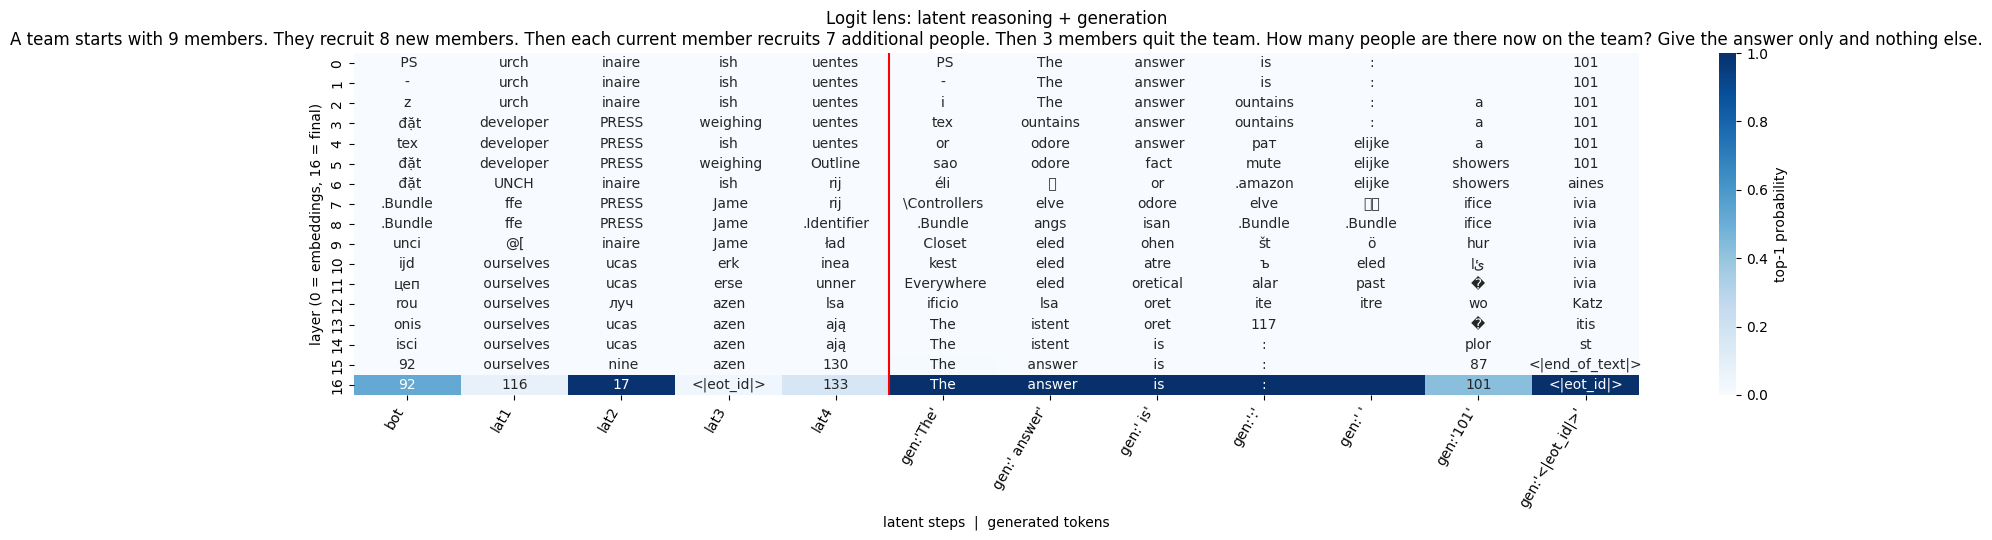

In [ ]:
def run_full_trace(question, num_latent=4, max_new_tokens=200):
    """Same latent-step logit-lens trace as before, extended through the
    actual answer-generation phase (post-eot), so you can see where the
    final number actually forms/breaks."""
    input_ids, attention_mask = encode_prompt(question)  # your existing helper (adds bot_id)

    step_tokens, step_probs, col_labels = [], [], []

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                         use_cache=True, output_hidden_states=True)
        past_key_values = outputs.past_key_values

        tok, prob = decode_all_layers(outputs.hidden_states)
        step_tokens.append(tok); step_probs.append(prob); col_labels.append("bot")

        latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
        latent_embd = prj(latent_embd)

        for i in range(num_latent):
            outputs = model(inputs_embeds=latent_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values
            tok, prob = decode_all_layers(outputs.hidden_states)
            step_tokens.append(tok); step_probs.append(prob); col_labels.append(f"lat{i+1}")
            latent_embd = outputs.hidden_states[-1][:, -1, :].unsqueeze(1)
            latent_embd = prj(latent_embd)

        # --- generation phase: same decode_all_layers trick, now on REAL
        #     generated tokens, using the raw (non-prj'd) eot embedding ---
        eot_embd = model.model.embed_tokens(
            torch.tensor([[ori_vocab_size + 2]], device=model.device)
        )
        next_embd = eot_embd
        for g in range(max_new_tokens):
            outputs = model(inputs_embeds=next_embd, use_cache=True,
                             output_hidden_states=True, past_key_values=past_key_values)
            past_key_values = outputs.past_key_values

            tok, prob = decode_all_layers(outputs.hidden_states)
            logits = outputs.logits[:, -1, :ori_vocab_size + 2]
            next_id = torch.argmax(logits, dim=-1)
            gen_tok_str = tokenizer.decode([next_id.item()])
            step_tokens.append(tok); step_probs.append(prob)
            col_labels.append(f"gen:{gen_tok_str!r}")

            if next_id.item() == tokenizer.eos_token_id:
                break
            next_embd = model.model.embed_tokens(next_id.unsqueeze(0))

    return step_tokens, step_probs, col_labels


def plot_full_trace(step_tokens, step_probs, col_labels, question, n_latent):
    probs_grid = np.array(step_probs).T
    tokens_grid = np.array(step_tokens).T

    fig, ax = plt.subplots(figsize=(1.4 * len(col_labels), 5.5))
    sns.heatmap(probs_grid, annot=tokens_grid, fmt="", cmap="Blues", vmin=0, vmax=1,
                xticklabels=col_labels, cbar_kws={"label": "top-1 probability"}, ax=ax)
    ax.axvline(n_latent + 1, color="red", linewidth=1.5)  # marks latent -> generation boundary
    ax.set_xlabel("latent steps  |  generated tokens")
    ax.set_ylabel("layer (0 = embeddings, 16 = final)")
    ax.set_title(f"Logit lens: latent reasoning + generation\n{question}")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()


question = "A team starts with 9 members. They recruit 8 new members. Then each current member recruits 7 additional people. Then 3 members quit the team. How many people are there now on the team? Give the answer only and nothing else."
step_tokens, step_probs, col_labels = run_full_trace(question, num_latent=4)
plot_full_trace(step_tokens, step_probs, col_labels, question, n_latent=4)